In [1]:
import h5py
from matplotlib import pyplot as plt

In [2]:
fn = h5py.File('Fixed_step/new_1/re_vgm_sand_10m_1d.h5', 'r')
f_FCT=h5py.File('Fixed_step/new_FCT/re_vgm_sand_10m_1d.h5', 'r')

elements_n = fn['elementsSpatial_Domain0'][:]
nodes_n = fn['nodesSpatial_Domain0'][:]
psi_n = fn['pressure_head_t0'][:]

elements_FCT = f_FCT['elementsSpatial_Domain0'][:]
nodes_FCT = f_FCT['nodesSpatial_Domain0'][:]
psi_FCT = f_FCT['pressure_head_t0'][:]


In [3]:
for key in fn:
    if key.startswith("pressure_head_t"):
        print(key)


pressure_head_t0
pressure_head_t1
pressure_head_t10
pressure_head_t100
pressure_head_t1000
pressure_head_t101
pressure_head_t102
pressure_head_t103
pressure_head_t104
pressure_head_t105
pressure_head_t106
pressure_head_t107
pressure_head_t108
pressure_head_t109
pressure_head_t11
pressure_head_t110
pressure_head_t111
pressure_head_t112
pressure_head_t113
pressure_head_t114
pressure_head_t115
pressure_head_t116
pressure_head_t117
pressure_head_t118
pressure_head_t119
pressure_head_t12
pressure_head_t120
pressure_head_t121
pressure_head_t122
pressure_head_t123
pressure_head_t124
pressure_head_t125
pressure_head_t126
pressure_head_t127
pressure_head_t128
pressure_head_t129
pressure_head_t13
pressure_head_t130
pressure_head_t131
pressure_head_t132
pressure_head_t133
pressure_head_t134
pressure_head_t135
pressure_head_t136
pressure_head_t137
pressure_head_t138
pressure_head_t139
pressure_head_t14
pressure_head_t140
pressure_head_t141
pressure_head_t142
pressure_head_t143
pressure_head_t144
p

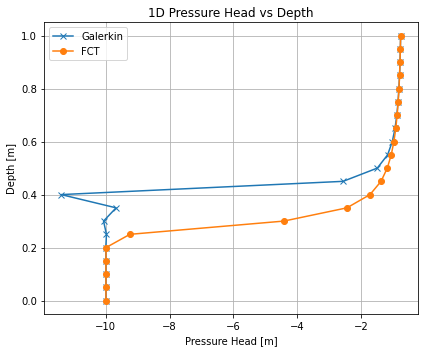

In [4]:
import matplotlib.pyplot as plt

# Pressure head from both FCT and Galerkin solutions
#psi2_n = fn['pressure_head_t{0}'.format()][:]   
psi5_n = fn['pressure_head_t{0}'.format(1000)][:] 
psi5_FCT = f_FCT['pressure_head_t{0}'.format(1000)][:] 

z_n = nodes_n[:, 0]
z_FCT = nodes_FCT[:, 0]


plt.figure(figsize=(6, 5))

#plt.plot(psi2_n, z_n, 'o-',label=None)
plt.plot(psi5_n,z_n,  'x-' ,  label="Galerkin")
plt.plot(psi5_FCT,z_FCT,  'o-' ,  label="FCT")


#plt.plot(psi10_FCT, z_FCT, label=None)
#plt.plot(psi10_G,     z_G,     label='Galerkin')

plt.xlabel('Pressure Head [m]')
plt.ylabel('Depth [m]')
#plt.gca().invert_yaxis()  # Top of column at top of plot
plt.title('1D Pressure Head vs Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('1d_pressure_profiles.png')
plt.show()


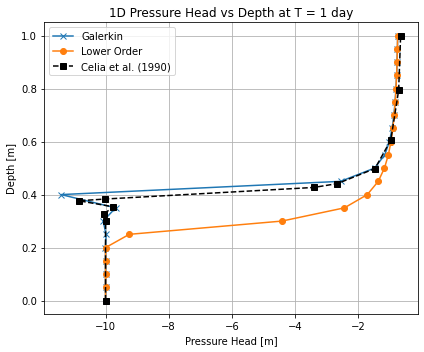

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Load Celia benchmark data from CSV ---
csv_data = pd.read_csv("data_celia_n.csv", header=None)
z_celia = csv_data[0].values / 100.0  # convert cm to meters
psi_celia = csv_data[1].values / 100.0  # convert cm to meters

# --- Load your numerical results ---
psi5_n = fn['pressure_head_t{0}'.format(1000)][:] 
psi5_FCT = f_FCT['pressure_head_t{0}'.format(1000)][:] 
z_n = nodes_n[:, 0]
z_FCT = nodes_FCT[:, 0]

# --- Plotting ---
plt.figure(figsize=(6, 5))

plt.plot(psi5_n, z_n, 'x-', label="Galerkin")
plt.plot(psi5_FCT, z_FCT, 'o-', label="Lower Order")
plt.plot(psi_celia, z_celia, 's--', label="Celia et al. (1990)", color='black')

plt.xlabel('Pressure Head [m]')
plt.ylabel('Depth [m]')
#plt.gca().invert_yaxis()  # Top of column at top of plot
plt.title('1D Pressure Head vs Depth at T = 1 day')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('1d_pressure_profiles_with_celia.png')
plt.show()


In [6]:
import xml.etree.ElementTree as ET
root= ET.fromstring(fn['Mesh_Spatial_Domain_1000'][:])
root.findall('Time')[0].attrib

{'Value': '1.000000e+00', 'Name': '1000'}